# <mark>Efficient Benchmark Tutorial: RF-DETR vs YOLO26 vs RT-DETR</mark>

This notebook is written as a practical, step-by-step tutorial for comparing three object detection models in Colab.

What you will learn:
- how to set up a reproducible benchmark harness
- how to test **FP32 vs FP16** inference
- how to test **batch-size scaling**
- how to visualize model performance with Seaborn
- how to do a qualitative side-by-side detection check on multiple images

What this notebook measures:
- `avg_ms`: mean latency per benchmark run
- `median_ms`: median latency (usually more stable than mean)
- `p95_ms`: tail latency (higher means occasional slow runs)
- `throughput_img_s`: images processed per second

Tip:
For fair comparisons, keep the same Colab runtime and rerun all cells after runtime restarts.


## <mark>Step 1: Clone project folder with sparse checkout</mark>

Why this step exists:
- The source images and benchmark assets live inside a large repo.
- We use **sparse checkout** so Colab downloads only the target subfolder instead of the full repository.

Expected outcome:
- Current working directory becomes `learnopencv/Inference_RF-DETR_YOLO26_RT-DETR`.


In [1]:
import os

# If the repository is not present yet, clone only git metadata and selected paths.
# This is faster and lighter than cloning the full repository contents.
if not os.path.exists("learnopencv"):
    !git clone --filter=blob:none --no-checkout https://github.com/Sudip-329/learnopencv.git

# Move into the repository root.
%cd learnopencv

# Initialize sparse checkout so we can pull just one folder.
!git sparse-checkout init --cone

# Keep only the benchmark project directory in the working tree.
!git sparse-checkout set Inference_RF-DETR_YOLO26_RT-DETR

# Materialize files from the checked out branch.
!git checkout

# Enter the benchmark folder.
%cd Inference_RF-DETR_YOLO26_RT-DETR

# Print location so all later relative paths are predictable.
print(f"Current working directory: {os.getcwd()}")


Cloning into 'learnopencv'...
remote: Enumerating objects: 8080, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 8080 (delta 21), reused 10 (delta 10), pack-reused 8038 (from 3)
Receiving objects: 100% (8080/8080), 2.18 MiB | 6.69 MiB/s, done.
Resolving deltas: 100% (3140/3140), done.
/content/learnopencv
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 1 (from 1)
Receiving objects: 100% (6/6), 25.10 MiB | 16.03 MiB/s, done.
Updating files: 100% (6/6), done.
Your branch is up to date with 'origin/master'.
/content/learnopencv/Inference_RF-DETR_YOLO26_RT-DETR
Current working directory: /content/learnopencv/Inference_RF-DETR_YOLO26_RT-DETR


## <mark>Step 2: Install required libraries</mark>

Why this step exists:
- We install only the libraries needed for benchmarking + plotting.
- Keeping the environment small reduces startup time and dependency conflicts.

Packages used:
- `rfdetr`: RF-DETR model API
- `ultralytics`: YOLO26 and RT-DETR APIs
- `seaborn`, `pandas`: analysis and plotting


In [ ]:
# Remove torchaudio to reduce potential binary dependency friction in Colab GPU runtimes.
# (This is optional, but often helps avoid environment conflicts in notebook sessions.)
!pip uninstall -y torchaudio

# Install only what we need for this tutorial.
# -q keeps installation logs compact.
!pip install -q rfdetr ultralytics seaborn pandas


Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.2/189.2 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.

## <mark>Step 3: Build a reusable benchmark harness</mark>

In this section we define:
- configuration knobs (image, warmup, runs, batch sizes, precision)
- model loaders
- standardized inference wrappers
- latency/throughput measurement utilities

Design goal:
Every model should go through the same benchmark path so the comparison is fair.


In [ ]:
import gc
import os
import time
import warnings
from contextlib import nullcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from rfdetr import RFDETRLarge
from ultralytics import RTDETR, YOLO

# Suppress noisy warnings so benchmark logs stay readable.
warnings.filterwarnings("ignore")

# ==========================================================
# Benchmark Configuration
# ==========================================================
# Image used for latency and throughput measurements.
IMAGE_PATH = "crowd.png"

# Detection confidence threshold used across all models.
CONFIDENCE_THRESHOLD = 0.5

# Warmup iterations are excluded from final timing stats.
# Warmup helps stabilize measurements by removing cold-start effects.
WARMUP_ITERS = 10

# Number of timed benchmark iterations per configuration.
BENCHMARK_RUNS = 50

# Batch sizes to compare. Keep these modest in Colab to avoid OOM.
BATCH_SIZES = [1, 2, 4]

# Detect execution device once and reuse throughout notebook.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Build an explicit runtime tag for plots and logs.
# This includes the exact GPU model name (for example: NVIDIA L4, Tesla T4, A100-SXM4-40GB).
if DEVICE == "cuda":
    GPU_NAME = torch.cuda.get_device_name(0)
    DEVICE_TAG = f"Device: CUDA ({GPU_NAME})"
else:
    GPU_NAME = "CPU"
    DEVICE_TAG = "Device: CPU"

# FP16 benchmarking only makes sense on CUDA.
FP16_MODES = [False, True] if DEVICE == "cuda" else [False]

# Print a clear runtime summary once at setup time.
print(DEVICE_TAG)


def sync_device() -> None:
    """Synchronize GPU work before timing boundaries.

    CUDA kernels are asynchronous by default.
    Without synchronization, measured latency would be artificially low.
    """
    if DEVICE == "cuda":
        torch.cuda.synchronize()


def clear_memory() -> None:
    """Release Python and CUDA memory between model runs."""
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


def fp16_context(enabled: bool):
    """Return autocast context for FP16 runs, otherwise no-op context."""
    if enabled and DEVICE == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


# ----------------------------------------------------------
# Model loaders
# ----------------------------------------------------------
def load_rfdetr():
    """Load RF-DETR Large and enable its inference optimizations."""
    model = RFDETRLarge()
    model.optimize_for_inference()
    return model


def load_yolo26():
    """Load YOLO26 Large weights from Ultralytics."""
    return YOLO("yolo26l.pt")


def load_rtdetr():
    """Load RT-DETR Large weights from Ultralytics."""
    return RTDETR("rtdetr-l.pt")


def supports_rfdetr_native_batch(model, sample_image) -> bool:
    """Check whether RF-DETR supports list-based batched prediction.

    Some model APIs expect single images only.
    If batch inference is unsupported, we fall back to sequential calls.
    """
    try:
        _ = model.predict([sample_image, sample_image], threshold=CONFIDENCE_THRESHOLD)
        return True
    except Exception:
        return False


# ----------------------------------------------------------
# Unified inference wrappers
# ----------------------------------------------------------
def infer_rfdetr(model, batch_images, fp16=False, native_batch=False):
    """Run RF-DETR inference for a batch using native or fallback mode."""
    with fp16_context(fp16):
        if native_batch:
            # Fast path: pass all images at once if the API supports it.
            return model.predict(batch_images, threshold=CONFIDENCE_THRESHOLD)

        # Fallback path: run each image one-by-one.
        outputs = []
        for image in batch_images:
            outputs.append(model.predict(image, threshold=CONFIDENCE_THRESHOLD))
        return outputs


def infer_ultralytics(model, batch_images, fp16=False):
    """Run Ultralytics models (YOLO26 / RT-DETR) on single image or batch."""
    source = batch_images if len(batch_images) > 1 else batch_images[0]
    return model(source, conf=CONFIDENCE_THRESHOLD, verbose=False, half=fp16)


def benchmark_config(model_name, model, infer_fn, batch_images, fp16=False):
    """Benchmark one exact configuration (model + precision + batch size)."""
    # -----------------------------
    # 1) Warmup phase (not timed)
    # -----------------------------
    for _ in range(WARMUP_ITERS):
        _ = infer_fn(model, batch_images, fp16)
    sync_device()

    # -----------------------------
    # 2) Timed benchmark phase
    # -----------------------------
    timings = []
    for _ in range(BENCHMARK_RUNS):
        start = time.perf_counter()
        _ = infer_fn(model, batch_images, fp16)
        sync_device()
        timings.append((time.perf_counter() - start) * 1000.0)

    timings = np.array(timings, dtype=np.float64)
    median_ms = float(np.median(timings))

    # Throughput is derived from median latency for robustness.
    return {
        "model": model_name,
        "precision": "FP16" if fp16 else "FP32",
        "batch_size": len(batch_images),
        "avg_ms": float(np.mean(timings)),
        "median_ms": median_ms,
        "p95_ms": float(np.percentile(timings, 95)),
        "throughput_img_s": float(len(batch_images) * 1000.0 / median_ms),
    }


def run_benchmarks(image_path=IMAGE_PATH):
    """Execute full benchmark sweep across models, precision modes, and batches."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    # Load image once and duplicate into cached batches to avoid repeated disk IO.
    base_image = Image.open(image_path).convert("RGB")
    batch_cache = {bs: [base_image.copy() for _ in range(bs)] for bs in BATCH_SIZES}

    # Unified benchmark spec: (display name, loader, inference wrapper).
    model_specs = [
        ("RF-DETR Large", load_rfdetr, infer_rfdetr),
        ("YOLO26 Large", load_yolo26, infer_ultralytics),
        ("RT-DETR Large", load_rtdetr, infer_ultralytics),
    ]

    rows = []

    for model_name, loader, infer_impl in model_specs:
        print(f"\n{'=' * 60}\nLoading {model_name}")
        model = loader()

        # RF-DETR may or may not support native list batching depending on backend.
        native_batch = False
        if model_name == "RF-DETR Large":
            native_batch = supports_rfdetr_native_batch(model, base_image)
            mode = "native" if native_batch else "sequential fallback"
            print(f"RF-DETR batch mode: {mode}")

        try:
            for fp16 in FP16_MODES:
                precision = "FP16" if fp16 else "FP32"
                print(f"\nPrecision: {precision}")

                # Adapter closure so benchmark_config can call a single function signature.
                def infer_fn(m, batch_images, use_fp16):
                    if model_name == "RF-DETR Large":
                        return infer_impl(m, batch_images, use_fp16, native_batch=native_batch)
                    return infer_impl(m, batch_images, use_fp16)

                for batch_size in BATCH_SIZES:
                    try:
                        metrics = benchmark_config(
                            model_name=model_name,
                            model=model,
                            infer_fn=infer_fn,
                            batch_images=batch_cache[batch_size],
                            fp16=fp16,
                        )
                    except Exception as exc:
                        # Skip only the failing configuration; continue benchmarking others.
                        print(f"bs={batch_size:<2} | skipped ({exc})")
                        continue

                    rows.append(metrics)
                    print(
                        f"bs={batch_size:<2} | median={metrics['median_ms']:.2f} ms | "
                        f"p95={metrics['p95_ms']:.2f} ms | throughput={metrics['throughput_img_s']:.2f} img/s"
                    )
        finally:
            # Free model memory before moving to the next model.
            del model
            clear_memory()

    # Return tidy table for later plotting and summary analysis.
    return pd.DataFrame(rows).sort_values(["model", "precision", "batch_size"]).reset_index(drop=True)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: CUDA (NVIDIA A100-SXM4-80GB)


## <mark>Step 4: Run the full benchmark sweep</mark>

This cell runs every configured combination:
- models: RF-DETR Large, YOLO26 Large, RT-DETR Large
- precision: FP32 (+ FP16 on CUDA)
- batch sizes: 1, 2, 4

Expected output:
A `pandas.DataFrame` where each row is one benchmark configuration.


#### GPU - Tesla T4

In [ ]:
# Execute the benchmark pipeline.
# This can take a few minutes depending on model downloads and Colab GPU load.
results_df = run_benchmarks(IMAGE_PATH)

# Display tabular results for inspection and plotting.
results_df



Loading RF-DETR Large
[2026-02-24 09:44:47] [INFO] rf-detr - Downloading pretrained weights for rf-detr-large-2026.pth


rf-detr-large-2026.pth:   0%|          | 0.00/130M [00:00<?, ?iB/s]

[2026-02-24 09:44:50] [INFO] rf-detr - MD5 validation successful for rf-detr-large-2026.pth


[2026-02-24 09:44:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-02-24 09:44:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-02-24 09:44:52] [INFO] rf-detr - Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


RF-DETR batch mode: sequential fallback

Precision: FP32
bs=1  | median=244.58 ms | p95=473.39 ms | throughput=4.09 img/s
bs=2  | median=293.38 ms | p95=367.64 ms | throughput=6.82 img/s
bs=4  | median=586.06 ms | p95=767.72 ms | throughput=6.83 img/s

Precision: FP16
bs=1  | median=139.17 ms | p95=187.49 ms | throughput=7.19 img/s
bs=2  | median=279.99 ms | p95=366.01 ms | throughput=7.14 img/s
bs=4  | median=565.65 ms | p95=1921.74 ms | throughput=7.07 img/s

Loading YOLO26 Large

Precision: FP32
bs=1  | median=57.27 ms | p95=66.09 ms | throughput=17.46 img/s
bs=2  | median=112.63 ms | p95=167.39 ms | throughput=17.76 img/s
bs=4  | median=229.03 ms | p95=324.16 ms | throughput=17.46 img/s

Precision: FP16
bs=1  | median=56.38 ms | p95=61.95 ms | throughput=17.74 img/s
bs=2  | median=112.23 ms | p95=162.81 ms | throughput=17.82 img/s
bs=4  | median=229.35 ms | p95=324.63 ms | throughput=17.44 img/s

Loading RT-DETR Large

Precision: FP32
bs=1  | median=86.67 ms | p95=132.14 ms | throu

,model,precision,batch_size,avg_ms,median_ms,p95_ms,throughput_img_s
0,RF-DETR Large,FP16,1,149.502762,139.171514,187.492205,7.185378
1,RF-DETR Large,FP16,2,296.629198,279.985945,366.007201,7.143216
2,RF-DETR Large,FP16,4,752.759090,565.647303,1921.738833,7.071544
3,RF-DETR Large,FP32,1,296.630002,244.579428,473.392452,4.088651
4,RF-DETR Large,FP32,2,301.085031,293.381940,367.635099,6.817052
5,RF-DETR Large,FP32,4,611.629559,586.058613,767.723583,6.825256
6,RT-DETR Large,FP16,1,97.202145,84.011379,131.266793,11.903150
7,RT-DETR Large,FP16,2,155.944246,154.635112,166.862987,12.933673
8,RT-DETR Large,FP16,4,319.913456,308.559529,405.986713,12.963463
9,RT-DETR Large,FP32,1,98.678892,86.666029,132.137853,11.538546


#### GPU - A100

In [ ]:
# Execute the benchmark pipeline.
# This can take a few minutes depending on model downloads and Colab GPU load.
results_df = run_benchmarks(IMAGE_PATH)

# Display tabular results for inspection and plotting.
results_df


Loading RF-DETR Large
[2026-02-24 09:59:17] [INFO] rf-detr - Downloading pretrained weights for rf-detr-large-2026.pth


rf-detr-large-2026.pth:   0%|          | 0.00/130M [00:00<?, ?iB/s]

[2026-02-24 09:59:25] [INFO] rf-detr - MD5 validation successful for rf-detr-large-2026.pth


[2026-02-24 09:59:25] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-02-24 09:59:25] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-02-24 09:59:25] [INFO] rf-detr - Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


RF-DETR batch mode: sequential fallback

Precision: FP32
bs=1  | median=62.20 ms | p95=70.85 ms | throughput=16.08 img/s
bs=2  | median=114.12 ms | p95=126.39 ms | throughput=17.53 img/s
bs=4  | median=238.39 ms | p95=260.54 ms | throughput=16.78 img/s

Precision: FP16
bs=1  | median=69.15 ms | p95=72.07 ms | throughput=14.46 img/s
bs=2  | median=140.44 ms | p95=155.28 ms | throughput=14.24 img/s
bs=4  | median=294.17 ms | p95=317.47 ms | throughput=13.60 img/s

Loading YOLO26 Large

Precision: FP32
bs=1  | median=58.91 ms | p95=59.50 ms | throughput=16.97 img/s
bs=2  | median=107.64 ms | p95=111.55 ms | throughput=18.58 img/s
bs=4  | median=184.93 ms | p95=191.58 ms | throughput=21.63 img/s

Precision: FP16
bs=1  | median=59.11 ms | p95=59.67 ms | throughput=16.92 img/s
bs=2  | median=107.11 ms | p95=112.85 ms | throughput=18.67 img/s
bs=4  | median=184.79 ms | p95=190.76 ms | throughput=21.65 img/s

Loading RT-DETR Large

Precision: FP32
bs=1  | median=78.41 ms | p95=79.51 ms | throu

,model,precision,batch_size,avg_ms,median_ms,p95_ms,throughput_img_s
0,RF-DETR Large,FP16,1,69.527944,69.153801,72.074236,14.460521
1,RF-DETR Large,FP16,2,144.030870,140.441019,155.279783,14.240854
2,RF-DETR Large,FP16,4,297.334543,294.174331,317.472297,13.597379
3,RF-DETR Large,FP32,1,61.197903,62.199527,70.850209,16.077293
4,RF-DETR Large,FP32,2,116.931111,114.117567,126.387762,17.525785
5,RF-DETR Large,FP32,4,240.334732,238.388684,260.540518,16.779320
6,RT-DETR Large,FP16,1,78.049635,77.954662,79.292835,12.827969
7,RT-DETR Large,FP16,2,119.025435,118.400936,121.873305,16.891758
8,RT-DETR Large,FP16,4,210.850472,210.807418,213.407608,18.974664
9,RT-DETR Large,FP32,1,78.578696,78.414705,79.511744,12.752710


## <mark>Step 5: Visualize results with Seaborn</mark>

We create two complementary plots:
- **Bar plot** for median latency by full configuration
- **Line plot** for throughput vs batch size

How to read them:
- Lower bar height in latency plot is better.
- Higher line in throughput plot is better.
- FP16 speedups are visible when FP16 curves/bars improve over FP32.


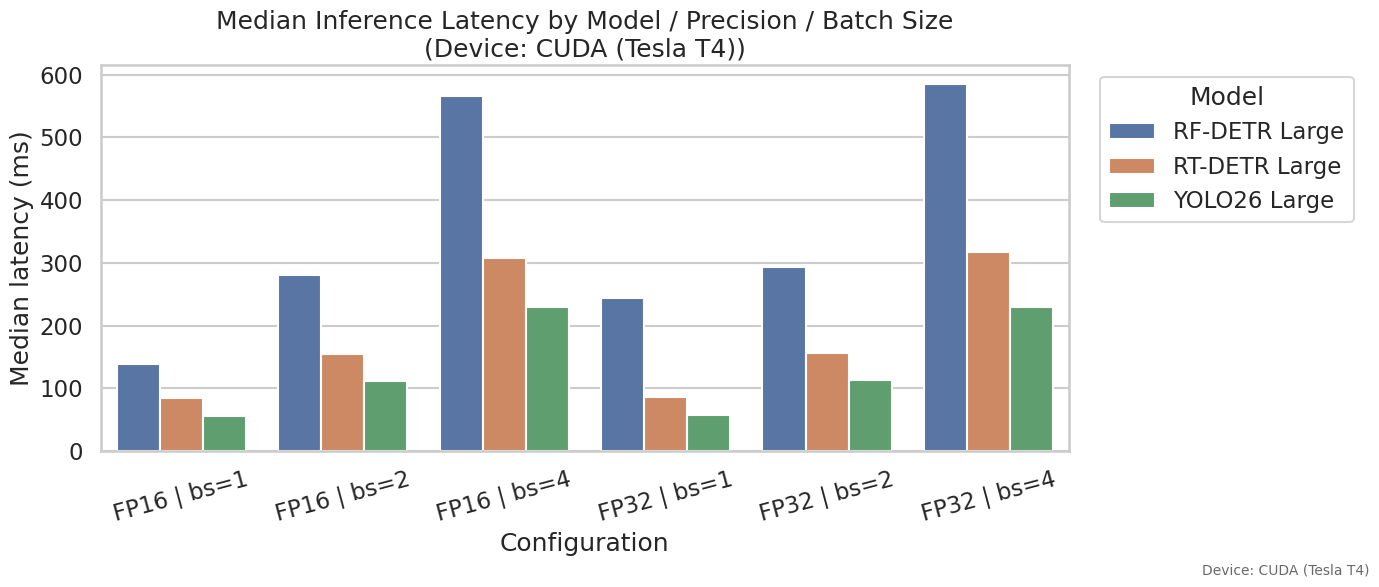

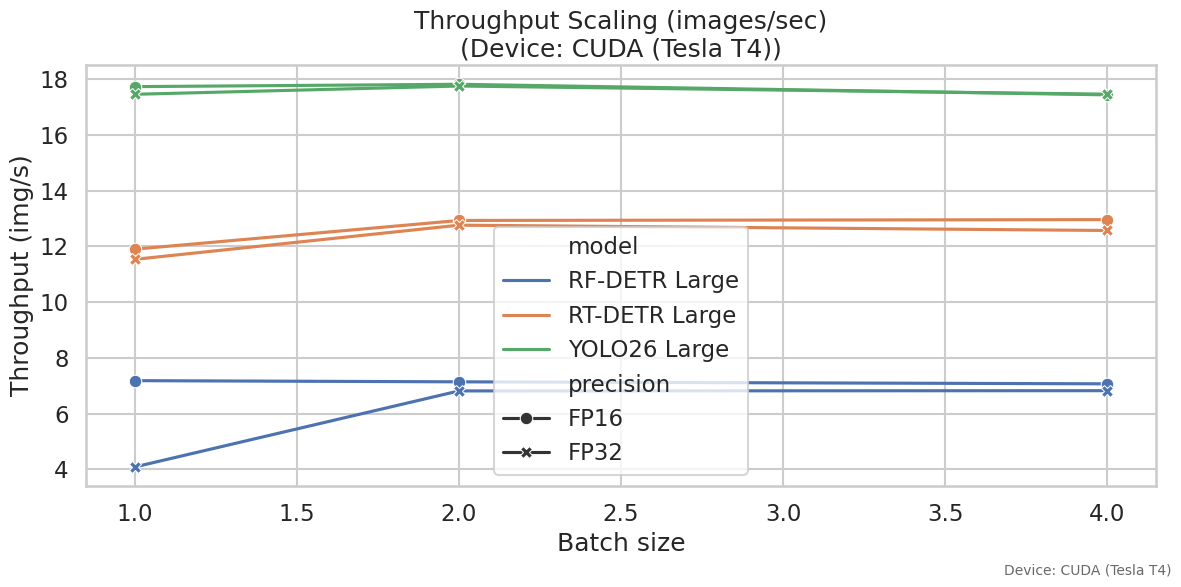

In [ ]:
# Use a clean, readable plotting theme for tutorial-style output.
sns.set_theme(style="whitegrid", context="talk")

# DEVICE_TAG is defined in the benchmark setup cell and includes exact GPU model details.

# Create a plotting copy so we can add derived display columns safely.
plot_df = results_df.copy()

# Human-readable configuration label shown on the x-axis.
plot_df["config"] = plot_df["precision"] + " | bs=" + plot_df["batch_size"].astype(str)

# ----------------------------------------------------------
# Plot 1: Median latency (bar chart)
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_df, x="config", y="median_ms", hue="model", ax=ax)
ax.set_title(f"Median Inference Latency by Model / Precision / Batch Size\n({DEVICE_TAG})")
ax.set_xlabel("Configuration")
ax.set_ylabel("Median latency (ms)")
plt.xticks(rotation=15)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

# Stamp device info into the figure area so it remains part of exported images.
fig.text(0.99, 0.01, DEVICE_TAG, ha="right", va="bottom", fontsize=10, color="dimgray")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Plot 2: Throughput scaling (line chart)
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=plot_df,
    x="batch_size",
    y="throughput_img_s",
    hue="model",
    style="precision",
    markers=True,
    dashes=False,
    ax=ax,
)
ax.set_title(f"Throughput Scaling (images/sec)\n({DEVICE_TAG})")
ax.set_xlabel("Batch size")
ax.set_ylabel("Throughput (img/s)")

# Repeat device stamp on the second plot for consistency.
fig.text(0.99, 0.01, DEVICE_TAG, ha="right", va="bottom", fontsize=10, color="dimgray")

plt.tight_layout()
plt.show()


## <mark>Step 6: Extract the best configurations</mark>

This section answers two practical questions:
- which configuration gives the **lowest median latency**?
- which configuration gives the **highest throughput**?

These two winners are often different, so pick the one aligned with your deployment goal.


In [ ]:
# Identify the fastest single-request style configuration (lowest median latency).
best_latency = results_df.loc[results_df["median_ms"].idxmin()]

# Identify the highest throughput configuration (best images/sec).
best_throughput = results_df.loc[results_df["throughput_img_s"].idxmax()]

print("Best latency config:")
print(best_latency.to_string())
print("\nBest throughput config:")
print(best_throughput.to_string())


Best latency config:
model               YOLO26 Large
precision                   FP16
batch_size                     1
avg_ms                 57.132562
median_ms                56.3827
p95_ms                 61.950883
throughput_img_s       17.735937

Best throughput config:
model               YOLO26 Large
precision                   FP16
batch_size                     2
avg_ms                124.621088
median_ms             112.227626
p95_ms                162.812179
throughput_img_s       17.820924


## <mark>Step 7: Qualitative comparison (visual sanity check)</mark>

Latency/throughput numbers are important, but we should also visually inspect detections.

This section:
- runs all three models on `cat.png`, `human.png`, and `crowd.png`
- draws predicted boxes + class labels
- renders a side-by-side grid for quick qualitative comparison

Why this helps:
A model can be fast but miss important objects, so always pair speed tests with visual checks.


Using FP16 for qualitative preview: True
Images: ['cat.png', 'human.png', 'crowd.png']
[2026-02-24 09:49:49] [INFO] rf-detr - File rf-detr-large-2026.pth already exists with correct MD5 hash.


[2026-02-24 09:49:49] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-02-24 09:49:49] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-02-24 09:49:50] [INFO] rf-detr - Loading pretrain weights


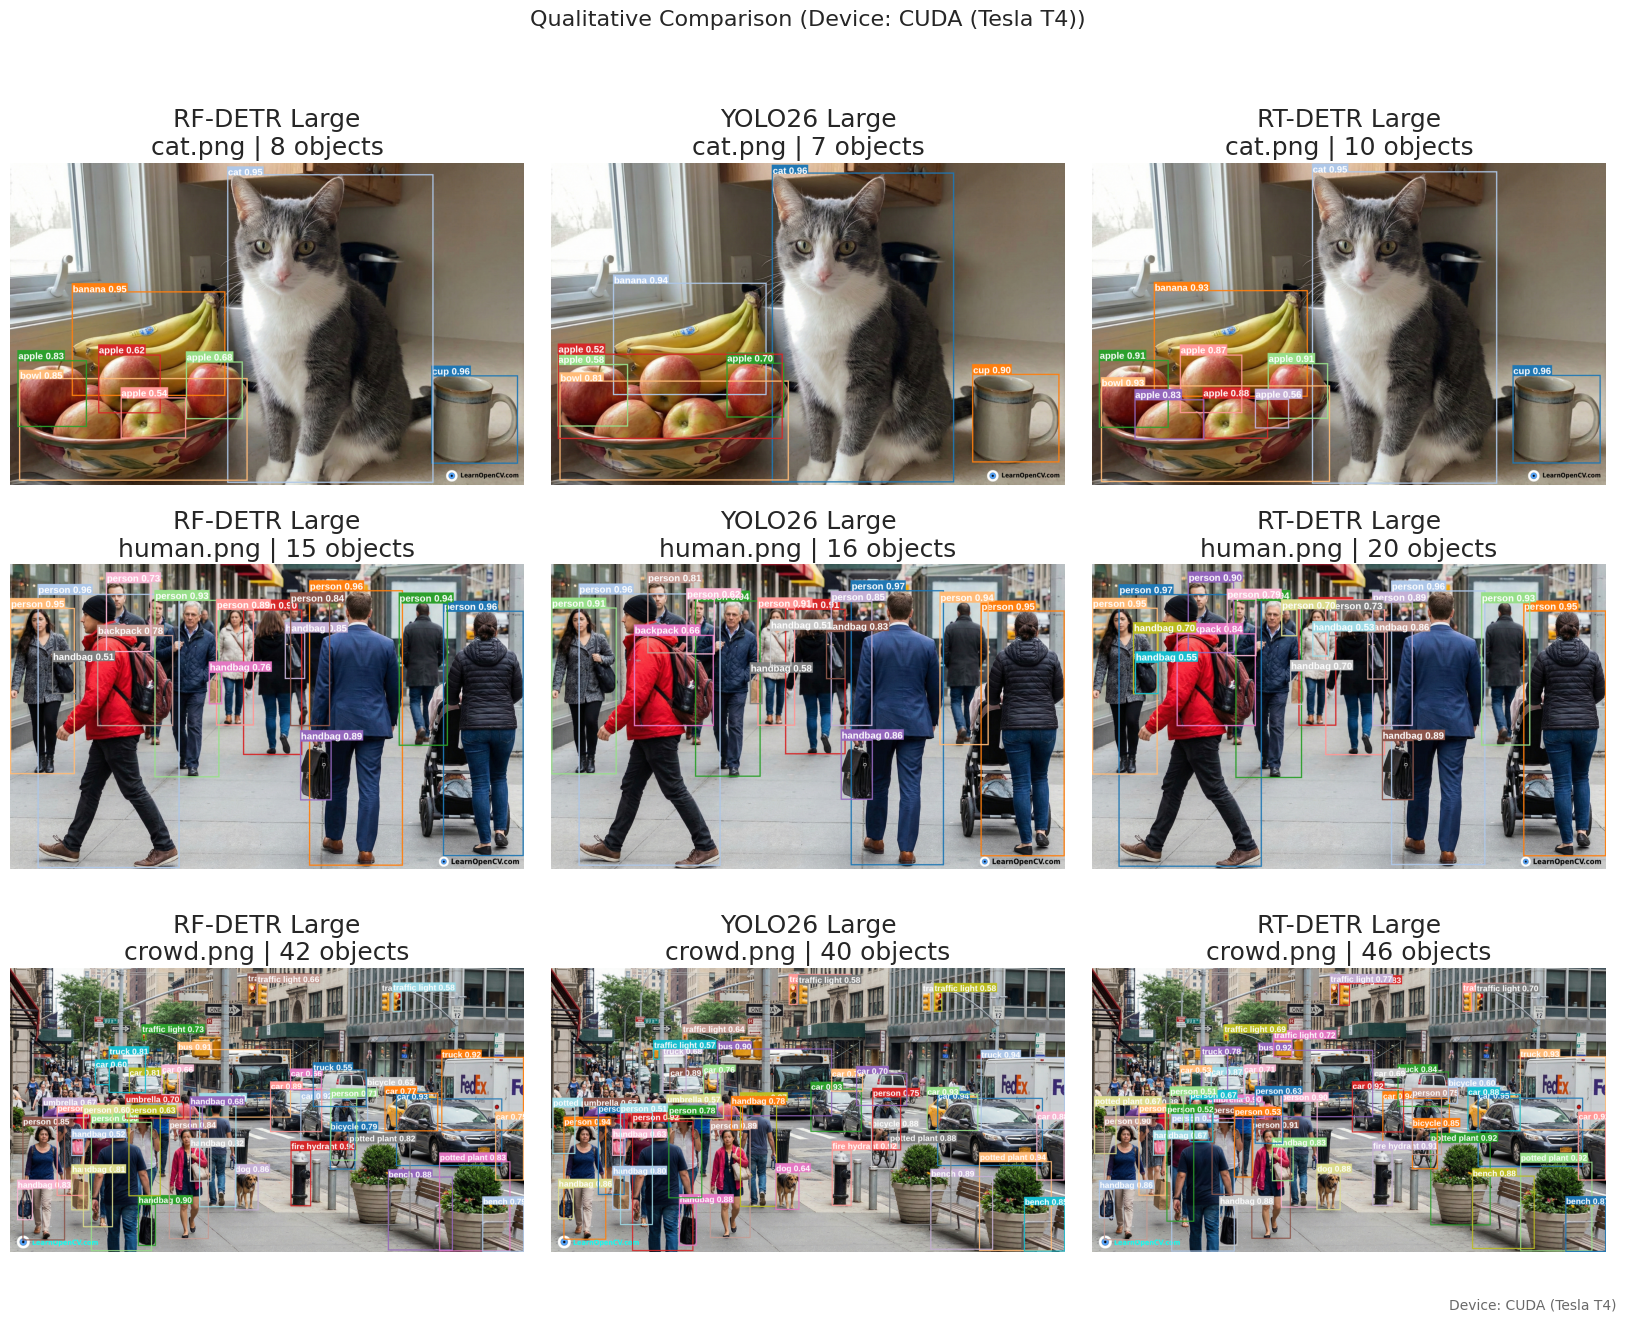

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from rfdetr.util.coco_classes import COCO_CLASSES
import os
import numpy as np
import matplotlib.pyplot as plt

# Images used for side-by-side qualitative comparison.
QUAL_IMAGES = ["cat.png", "human.png", "crowd.png"]

# Use FP16 previews on CUDA to mirror common deployment settings.
QUAL_FP16 = DEVICE == "cuda"

def _to_numpy(x):
    """Convert tensors/arrays/lists to numpy arrays safely."""
    if x is None:
        return np.array([])
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    elif hasattr(x, "cpu"):
        x = x.cpu().numpy()
    return np.asarray(x)

def _normalize_boxes(boxes):
    """Normalize box tensor to shape [N, 4] float32."""
    boxes = _to_numpy(boxes)
    if boxes.size == 0:
        return np.zeros((0, 4), dtype=np.float32)
    return boxes.reshape(-1, 4).astype(np.float32)

def _normalize_ids(ids):
    """Normalize class IDs to 1D int array."""
    ids = _to_numpy(ids)
    if ids.size == 0:
        return np.array([], dtype=np.int32)
    return ids.reshape(-1).astype(np.int32)

def _normalize_scores(scores):
    """Normalize confidence scores to 1D float array."""
    scores = _to_numpy(scores)
    if scores.size == 0:
        return np.array([], dtype=np.float32)
    return scores.reshape(-1).astype(np.float32)

def _annotate(pil_image, boxes, class_ids, scores, names):
    """Draw boxes + labels on a copy of the image and return a numpy array."""
    canvas = pil_image.copy()
    draw = ImageDraw.Draw(canvas)

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf", size=45)
    except IOError:
        font = ImageFont.load_default()

    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        cls_id = int(class_ids[i]) if i < len(class_ids) else -1
        score = float(scores[i]) if i < len(scores) else 0.0
        cls_name = names.get(cls_id, str(cls_id))
        label = f"{cls_name} {score:.2f}"

        # Pick a color from tab20 palette
        r, g, b, _ = plt.cm.tab20(i % 20)
        color = (int(r * 255), int(g * 255), int(b * 255))

        # Draw bounding box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=6)

        # Text background block
        try:
            left, top, right, bottom = draw.textbbox((0, 0), label, font=font)
            text_width = right - left
            text_height = bottom - top
        except AttributeError:
            text_width, text_height = draw.textsize(label, font=font)

        text_bg_y1 = max(0, y1 - text_height - 6)
        text_bg_y2 = text_bg_y1 + text_height + 6
        text_bg_x2 = x1 + text_width + 8

        draw.rectangle([x1, text_bg_y1, text_bg_x2, text_bg_y2], fill=color)
        draw.text((x1 + 4, text_bg_y1 + 2), label, fill="white", font=font)

    return np.array(canvas)

def _predict_rfdetr(model, image, fp16=False):
    """Run RF-DETR and normalize outputs to a common format."""
    with fp16_context(fp16):
        pred = model.predict(image, threshold=CONFIDENCE_THRESHOLD)

    boxes = _normalize_boxes(getattr(pred, "xyxy", None))
    class_ids = _normalize_ids(getattr(pred, "class_id", None))
    scores = _normalize_scores(getattr(pred, "confidence", None))

    if isinstance(COCO_CLASSES, dict):
        names = COCO_CLASSES
    else:
        names = {i: n for i, n in enumerate(COCO_CLASSES)}

    return boxes, class_ids, scores, names

def _predict_ultralytics(model, image, fp16=False):
    """Run Ultralytics model and normalize outputs to the same format."""
    result = model(image, conf=CONFIDENCE_THRESHOLD, verbose=False, half=fp16)[0]
    boxes_obj = result.boxes

    boxes = _normalize_boxes(getattr(boxes_obj, "xyxy", None))
    class_ids = _normalize_ids(getattr(boxes_obj, "cls", None))
    scores = _normalize_scores(getattr(boxes_obj, "conf", None))

    names_raw = result.names if hasattr(result, "names") else model.names
    if isinstance(names_raw, dict):
        names = {int(k): str(v) for k, v in names_raw.items()}
    else:
        names = {i: str(v) for i, v in enumerate(names_raw)}

    return boxes, class_ids, scores, names

# Keep only images that actually exist in the current working directory.
existing_images = [p for p in QUAL_IMAGES if os.path.exists(p)]
if not existing_images:
    raise FileNotFoundError(f"None of these images were found: {QUAL_IMAGES}")

print(f"Using FP16 for qualitative preview: {QUAL_FP16}")
print(f"Images: {existing_images}")

# Load all models once for fair side-by-side qualitative comparison.
models = [
    ("RF-DETR Large", load_rfdetr(), _predict_rfdetr),
    ("YOLO26 Large", load_yolo26(), _predict_ultralytics),
    ("RT-DETR Large", load_rtdetr(), _predict_ultralytics),
]

# Grid layout:
fig, axes = plt.subplots(
    nrows=len(existing_images),
    ncols=len(models),
    figsize=(5.5 * len(models), 4.3 * len(existing_images)),
)

# Normalize shape for single-row case.
if len(existing_images) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, image_path in enumerate(existing_images):
    pil_image = Image.open(image_path).convert("RGB")

    for col, (model_name, model, predict_fn) in enumerate(models):
        ax = axes[row, col]

        try:
            boxes, class_ids, scores, names = predict_fn(model, pil_image, fp16=QUAL_FP16)
            annotated = _annotate(pil_image, boxes, class_ids, scores, names)
            count = len(boxes)

            ax.imshow(annotated)
            ax.set_title(f"{model_name}\n{image_path} | {count} objects")
        except Exception as exc:
            ax.imshow(np.array(pil_image))
            ax.set_title(f"{model_name}\n{image_path} | error")
            print(f"{model_name} failed on {image_path}: {exc}")

        ax.axis("off")

fig.suptitle(f"Qualitative Comparison ({DEVICE_TAG})", y=1.02, fontsize=16)
fig.text(0.99, 0.01, DEVICE_TAG, ha="right", va="bottom", fontsize=10, color="dimgray")

plt.tight_layout(h_pad=1.0)
plt.show()

# Cleanup to release GPU memory.
for _, model, _ in models:
    del model
clear_memory()